In [21]:
import torch
from cryosim.icemaker import NaiveIcemaker
from cryosim.potential import GemmiPotentialBuilder, PotentialBuilder
from cryosim.pdbtools import PDB
from cryosim.plotting_tools import plot3d
import time

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
nxy = 1024
nz = 256
ni = NaiveIcemaker(1.0, nxy, nz)

In [48]:
ice_init = ni.create_initial_ice_volume()

In [49]:
ice_init.shape

torch.Size([256, 1024, 1024])

In [50]:
coords = torch.nonzero(ice_init == 1, as_tuple=False).type(torch.float32)
coords = coords[:, [2, 1, 0]]

In [51]:
centered = PDB.center_coordinates(coords)

In [52]:
gpb = GemmiPotentialBuilder(
    (nxy, nxy, nz), 1.0, atomic_numbers=torch.tensor([8] * len(centered))
)

In [53]:
pb = PotentialBuilder(
    (nxy, nxy, nz), 1.0, atomic_numbers=torch.tensor([8] * len(centered))
)

In [56]:
ni.n_ice_molecules

8434854

In [43]:
t0 = time.perf_counter()
with torch.no_grad():
    test = gpb.build_potential(centered)
t1 = time.perf_counter()
print(t1 - t0)

23.68065788038075


In [54]:
t0 = time.perf_counter()
with torch.no_grad():
    test_pd = pb(centered)
t1 = time.perf_counter()
print(t1 - t0)

Output()

2.114894950762391


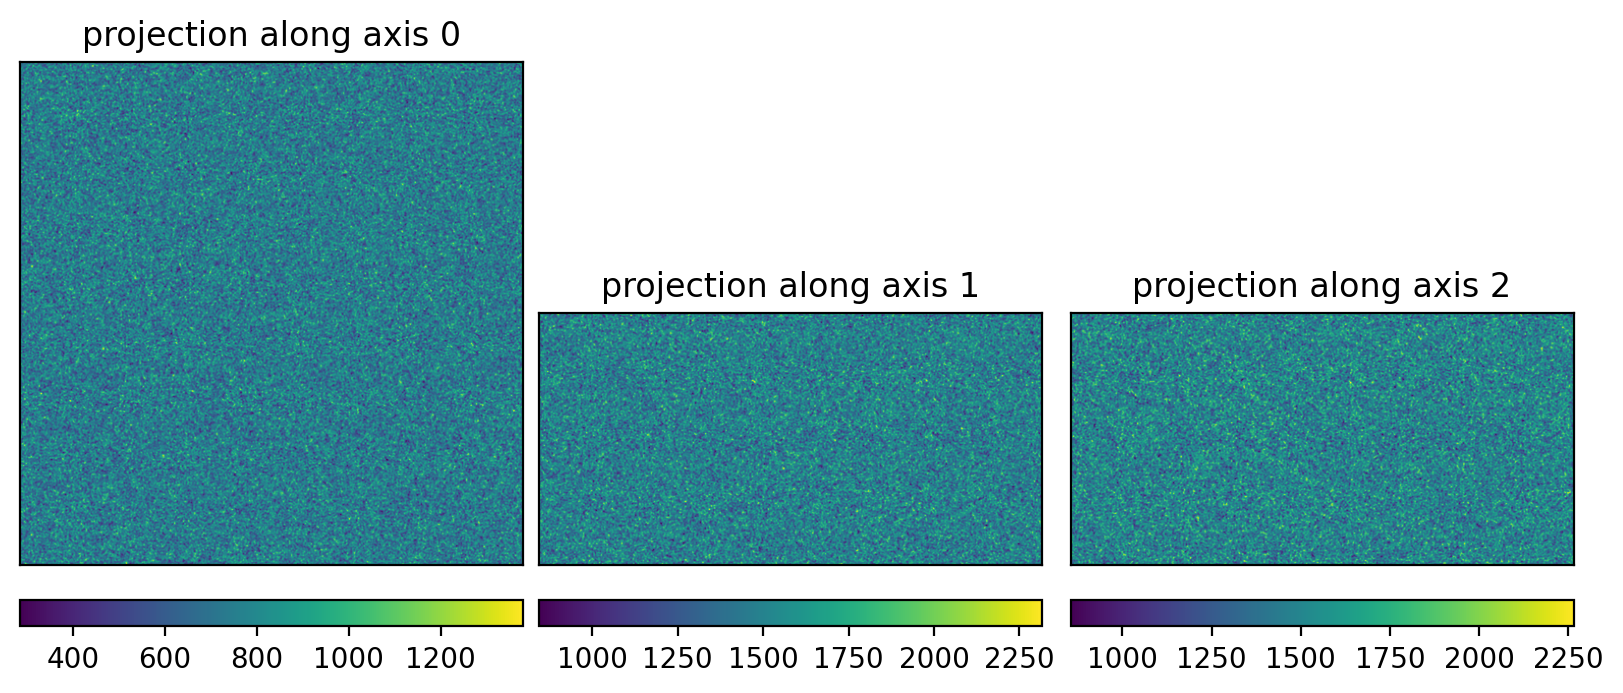

In [45]:
plot3d(test)

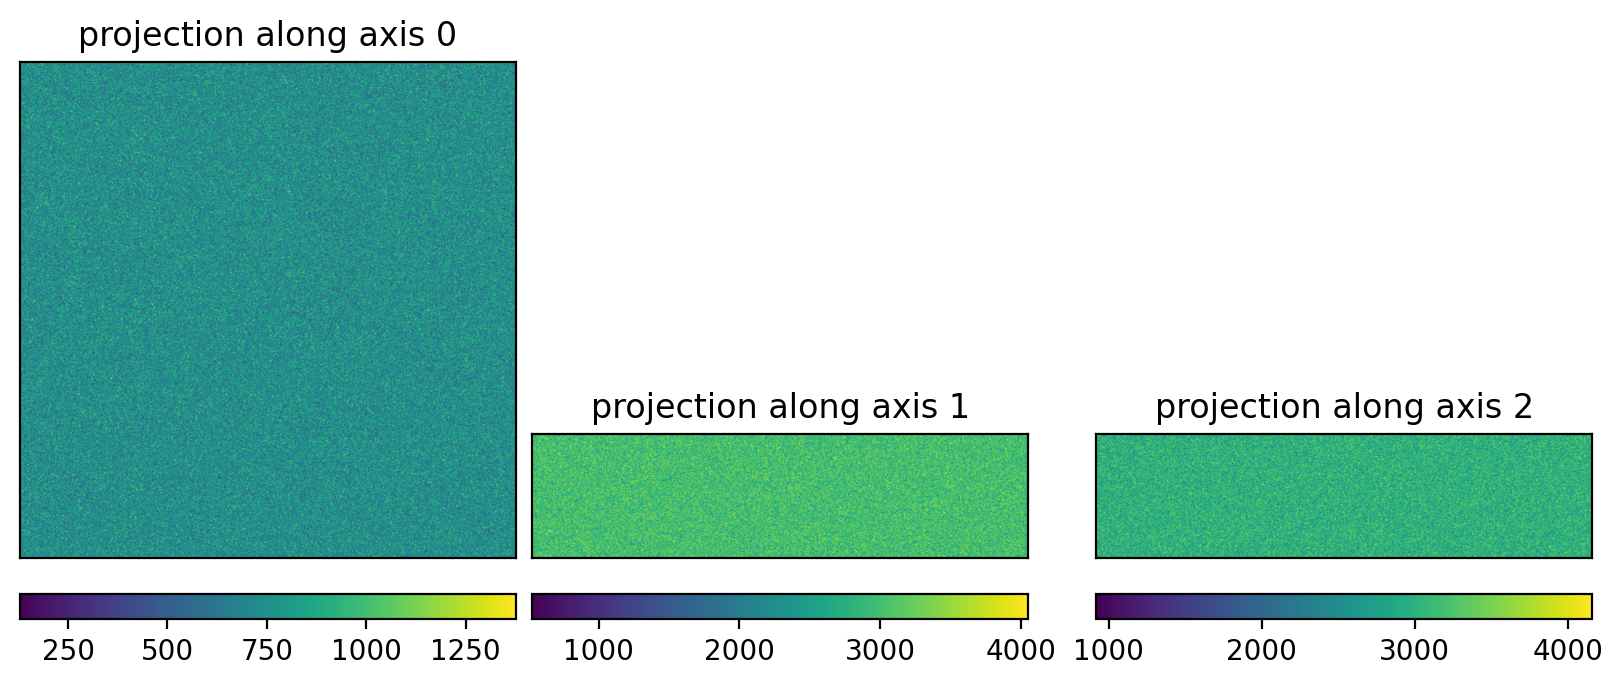

In [55]:
plot3d(test_pd)

In [37]:
test.shape

torch.Size([256, 512, 512])